# Data Cleaning & Exploratory Analysis — Seoul Bike Sharing Demand Classification

This notebook is the data-quality and exploratory-analysis stage of the classification pipeline for the Seoul Bike Sharing demand-prediction task (Saarland University ML core-lecture project). The learning target, `Demand_Category` ∈ {0 = Low, 1 = Normal, 2 = High}, is provided directly in `train.csv` as an integer label; consistent with the project's separation between the regression and classification tasks, the underlying `Rented Bike Count` field used to derive that label for the regression task does not appear anywhere in this dataset or notebook.

The goal here is twofold: first, to understand the real-world data-quality problems present in the raw training data — inconsistent category labels, missing sensor readings, and physically implausible measurements — before any model is trained on it; second, to produce several defensible, alternative cleaned versions of the training set rather than committing to a single cleaning strategy up front. Which combination of anomaly handling (drop vs. preserve-as-missing) and missing-value handling (drop vs. impute) works best is treated as an empirical question to be answered later by comparing model performance across variants, not a modeling decision made here.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

pd.set_option("display.max_columns", None)

df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

display(df_train.head())

Train shape: (7093, 16)
Test shape: (2628, 15)


,Kaggle_ID,Date,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day,Record_id,Demand_Category
0,0,15/05/2018,11,24.8,36,1.8,973,8.7,2.70,0.0,0.0,Sprng,No Holiday,Yes,5137441,1
1,1,7/9/2018,23,12.9,0,2.4,1688,50.9,0.00,2.4,1.4,Sproing,No Holiday,No,1465289,0
2,2,8/6/2018,21,21.2,77,1.7,638,16.9,0.00,0.0,0.0,Summr,No Holiday,Yes,13081158,2
3,3,3/2/2018,23,-10.0,48,2.6,2000,-18.9,0.00,0.0,0.0,Winteer,No Holiday,Yes,807953,0
4,4,20/07/2018,18,33.9,42,2.0,1969,19.1,1.25,0.0,0.0,Sumer,No Holiday,Yes,13313822,2


## 1. Structural and Distributional Overview

Before any cleaning is attempted, the raw training data is inspected along three axes: its schema (column types and cardinalities), the pattern of missing values across columns, and the balance of the target classes. The class-balance check in particular matters for metric choice: if one class dominates, a plain accuracy score can look good while ignoring the minority classes entirely. Macro-F1 — the metric specified for this task — instead averages the F1 score computed independently per class, so it penalizes poor performance on minority classes just as much as on the majority class. Confirming the actual degree of imbalance here is what justifies using macro-F1 downstream rather than accuracy.

In [2]:
print("TRAIN INFO")
df_train.info()

print("\nTRAIN SHAPE:", df_train.shape)
print("TEST SHAPE:", df_test.shape)

print("\nCOLUMN NAMES:")
print(df_train.columns.tolist())

TRAIN INFO
<class 'pandas.DataFrame'>
RangeIndex: 7093 entries, 0 to 7092
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Kaggle_ID              7093 non-null   int64  
 1   Date                   7093 non-null   str    
 2   Hour                   7093 non-null   int64  
 3   Temperature            6900 non-null   float64
 4   Humidity               7093 non-null   int64  
 5   Wind speed             6776 non-null   float64
 6   Visibility             7093 non-null   int64  
 7   Dew point temperature  7093 non-null   float64
 8   Solar Radiation        6447 non-null   float64
 9   Rainfall               6585 non-null   float64
 10  Snowfall               7093 non-null   float64
 11  Seasons                7093 non-null   str    
 12  Holiday                7093 non-null   str    
 13  Functioning Day        7093 non-null   str    
 14  Record_id              7093 non-null   int64  
 15  Dema

In [3]:
schema = pd.DataFrame({
    "dtype": df_train.dtypes,
    "missing": df_train.isna().sum(),
    "n_unique": df_train.nunique(),
})

display(schema)

,dtype,missing,n_unique
Kaggle_ID,int64,0,7093
Date,str,0,365
Hour,int64,0,34
Temperature,float64,193,549
Humidity,int64,0,91
Wind speed,float64,317,74
Visibility,int64,0,1681
Dew point temperature,float64,0,558
Solar Radiation,float64,646,340
Rainfall,float64,508,56


### Target class balance

`Demand_Category` has 3,534 Normal (1), 1,800 High (2), and 1,759 Low (0) observations — 49.8%, 25.4%, and 24.8% of the 7,093 training rows respectively. The two minority classes are of comparable size to each other but roughly half the size of the majority class, a moderate imbalance. This is precisely the setting macro-F1 is designed for: a classifier that mostly predicts the majority class would score well on accuracy but poorly on macro-F1, since the metric weights the Low- and High-demand classes equally with Normal regardless of their smaller support.

In [4]:
print(df_train["Demand_Category"].value_counts())
print()
print(df_train["Demand_Category"].value_counts(normalize=True))

Demand_Category
1    3534
2    1800
0    1759
Name: count, dtype: int64

Demand_Category
1    0.498238
2    0.253771
0    0.247991
Name: proportion, dtype: float64


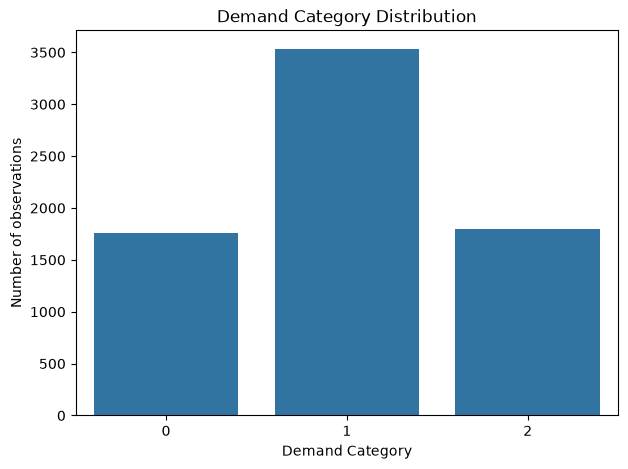

In [5]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_train,
    x="Demand_Category"
)

plt.title("Demand Category Distribution")
plt.xlabel("Demand Category")
plt.ylabel("Number of observations")
plt.show()

In [6]:
print("Missing target values:", df_train["Demand_Category"].isna().sum())

print("Unique target values:")
print(sorted(df_train["Demand_Category"].dropna().unique()))

Missing target values: 0
Unique target values:
[np.int64(0), np.int64(1), np.int64(2)]


In [7]:
print("Columns only in train:")
print(set(df_train.columns) - set(df_test.columns))

print("\nColumns only in test:")
print(set(df_test.columns) - set(df_train.columns))

Columns only in train:
{'Demand_Category'}

Columns only in test:
set()


In [8]:
X = df_train.drop(columns=["Demand_Category"])
y = df_train["Demand_Category"]

print(X.shape)
print(y.shape)

(7093, 15)
(7093,)


### Missingness pattern

Four columns carry missing values, all of them weather sensor readings: Solar Radiation (9.11%), Rainfall (7.16%), Wind speed (4.47%), and Temperature (2.72%). No other column — including the target — has any missing values. The missingness is concentrated in exactly the columns most likely to depend on functioning physical sensors, which is consistent with sporadic sensor dropout rather than a structural or target-dependent pattern (a per-class missingness breakdown later in the notebook confirms the missing rates are similar across all three demand classes).

In [9]:
missing = pd.DataFrame({
    "Missing count": df_train.isna().sum(),
    "Missing percentage": df_train.isna().mean() * 100
})

display(
    missing
    .sort_values("Missing percentage", ascending=False)
)

,Missing count,Missing percentage
Solar Radiation,646,9.107571
Rainfall,508,7.161991
Wind speed,317,4.469195
Temperature,193,2.720993
Hour,0,0.000000
Humidity,0,0.000000
Date,0,0.000000
Kaggle_ID,0,0.000000
Dew point temperature,0,0.000000
Visibility,0,0.000000


In [10]:
numeric_cols = df_train.select_dtypes(include=np.number).columns

display(
    df_train[numeric_cols].describe().T
)

,count,mean,std,min,25%,50%,75%,max
Kaggle_ID,7093.0,3.546000e+03,2.047717e+03,0.0,1773.0,3546.00,5319.00,7092.00
Hour,7093.0,1.001664e+01,8.281208e+00,-10.0,4.0,10.00,17.00,23.00
Temperature,6900.0,1.288371e+01,1.153236e+01,-37.2,4.4,13.00,21.80,55.80
Humidity,7093.0,5.805823e+01,1.973354e+01,0.0,44.0,58.00,72.00,98.00
Wind speed,6776.0,1.747934e+00,1.073620e+00,-2.0,1.0,1.70,2.30,15.70
Visibility,7093.0,1.431751e+03,5.825103e+02,0.0,1006.0,1548.00,1990.00,2500.00
Dew point temperature,7093.0,4.127999e+00,1.257683e+01,-34.7,-3.5,4.50,14.00,61.20
Solar Radiation,6447.0,5.699783e-01,8.373305e-01,0.0,0.0,0.07,0.78,3.52
Rainfall,6585.0,1.612301e-01,1.087672e+00,0.0,0.0,0.00,0.00,29.50
Snowfall,7093.0,7.472156e-02,4.092862e-01,0.0,0.0,0.00,0.00,8.80


### Categorical feature inspection

Turning to the categorical columns, `Date`, `Seasons`, `Holiday`, and `Functioning Day` are checked for the values they actually contain. `Holiday` and `Functioning Day` are clean binary flags, but `Seasons` — which should only take four values — turns out to hold 16 distinct strings, exposing a data-entry problem addressed next.

In [11]:
categorical_cols = df_train.select_dtypes(
    include=["object", "category"]
).columns

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df_train[col].value_counts(dropna=False))


--- Date ---
Date
28/07/2018    27
12/8/2018     27
12/2/2018     26
20/10/2018    26
21/11/2018    26
              ..
16/05/2018    13
3/8/2018      12
2/5/2018      12
30/04/2018    12
3/6/2018      10
Name: count, Length: 365, dtype: int64

--- Seasons ---
Seasons
Autumn     494
Summr      491
Summer     480
Autmn      460
Spring     459
Wintr      456
Wonter     446
Sprng      440
Sproing    440
Winteer    434
Winter     427
Sumer      422
Autum      422
Summmer    412
Spriing    411
Auttumn    399
Name: count, dtype: int64

--- Holiday ---
Holiday
No Holiday    6435
Holiday        658
Name: count, dtype: int64

--- Functioning Day ---
Functioning Day
Yes    6517
No      576
Name: count, dtype: int64


C:\Users\VivoBook Pro 16x\AppData\Local\Temp\ipykernel_18648\3608155908.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_train.select_dtypes(


### Fixing `Seasons` misspellings

The 16 distinct values found in `Seasons` are 12 misspelled variants of the four real seasons (e.g. `Sprng`, `Sproing`, `Wonter`, `Auttumn`) plus the four correctly spelled labels. A lookup table mapping each misspelling to its correct season collapses all 16 values down to the expected four: Summer (1,805), Autumn (1,775), Winter (1,763), Spring (1,750).

In [12]:
# 1. Define the dictionary of misspellings to correct
season_corrections = {
    # Autumn misspellings
    'Autmn': 'Autumn',
    'Autum': 'Autumn',
    'Auttumn': 'Autumn',
    
    # Summer misspellings
    'Summr': 'Summer',
    'Sumer': 'Summer',
    'Summmer': 'Summer',
    
    # Spring misspellings
    'Sprng': 'Spring',
    'Sproing': 'Spring',
    'Spriing': 'Spring',
    
    # Winter misspellings
    'Wintr': 'Winter',
    'Wonter': 'Winter',
    'Winteer': 'Winter'
}

# 2. Apply the corrections to the 'Seasons' column
df_train['Seasons'] = df_train['Seasons'].replace(season_corrections)

# Verify the corrections worked
print("Value counts for 'Seasons' after text correction:")
display(df_train['Seasons'].value_counts().to_frame(name='Count'))

Value counts for 'Seasons' after text correction:


,Count
Seasons,
Summer,1805
Autumn,1775
Winter,1763
Spring,1750


### Cross-checking `Seasons` against `Date`

Correcting spelling only guarantees that every row's `Seasons` value is one of the four valid labels — it does not guarantee that the label is the correct season for that row. Since every row also carries a `Date`, the calendar month implied by `Date` gives an independent, ground-truth season for each row (Mar–May = Spring, Jun–Aug = Summer, Sep–Nov = Autumn, Dec–Feb = Winter). Comparing the (spelling-corrected) declared season against this date-derived season surfaces any rows where the label itself is simply wrong, independent of spelling.

In [13]:
df_analysis = df_train.copy()

df_analysis["Date"] = pd.to_datetime(
    df_analysis["Date"],
    dayfirst=True,
    errors="coerce"
)

df_analysis["Year"] = df_analysis["Date"].dt.year
df_analysis["Month"] = df_analysis["Date"].dt.month
df_analysis["Day"] = df_analysis["Date"].dt.day
df_analysis["Weekday"] = df_analysis["Date"].dt.dayofweek

In [14]:
df_analysis["Derived_Season"] = df_analysis["Month"].map(
    lambda m:
        "Spring" if m in [3, 4, 5] else
        "Summer" if m in [6, 7, 8] else
        "Autumn" if m in [9, 10, 11] else
        "Winter"
)

In [15]:
for col in ["Year", "Month", "Weekday"]:
    print(f"\n--- {col} ---")
    display(
        pd.crosstab(
            df_analysis[col],
            df_analysis["Demand_Category"],
            normalize="index"
        )
    )


--- Year ---


Demand_Category,0,1,2
Year,,,
2017,0.385643,0.594324,0.020033
2018,0.235294,0.489375,0.275331



--- Month ---


Demand_Category,0,1,2
Month,,,
1,0.509967,0.475083,0.014950
2,0.466055,0.504587,0.029358
3,0.233169,0.669951,0.096880
4,0.267025,0.462366,0.270609
5,0.189236,0.361111,0.449653
6,0.067912,0.380306,0.551783
7,0.105090,0.548440,0.346470
8,0.103333,0.588333,0.308333
9,0.213333,0.383333,0.403333



--- Weekday ---


Demand_Category,0,1,2
Weekday,,,
0,0.242032,0.486056,0.271912
1,0.266667,0.480392,0.252941
2,0.225838,0.492110,0.282051
3,0.269461,0.489022,0.241517
4,0.226525,0.521781,0.251694
5,0.210680,0.516505,0.272816
6,0.296970,0.501010,0.202020


In [16]:
mismatch = df_analysis[
    df_analysis["Seasons"] != df_analysis["Derived_Season"]
]

print("Number of season mismatches:", len(mismatch))

display(
    mismatch[
        ["Date", "Seasons", "Derived_Season"]
    ].head(20)
)

Number of season mismatches: 495


,Date,Seasons,Derived_Season
1,2018-09-07,Spring,Autumn
26,2018-08-13,Spring,Summer
27,2018-02-12,Autumn,Winter
33,2018-08-07,Spring,Summer
43,2018-02-20,Autumn,Winter
45,2018-07-19,Winter,Summer
70,2018-03-13,Summer,Spring
84,2018-07-25,Spring,Summer
96,2018-03-04,Winter,Spring
101,2018-09-22,Winter,Autumn


### Resolving the mismatch: re-deriving `Seasons` from `Date`

495 rows have a declared `Seasons` value that disagrees with the season implied by their own `Date`, even after the 12 misspellings above were corrected. Patching these individually would require deciding, row by row, whether the `Seasons` value or the `Date` value is the one at fault — with no independent way to tell. Re-deriving `Seasons` directly from `Date` for every row sidesteps that ambiguity entirely: it fixes the 495 mismatches and any remaining spelling variants in a single, deterministic step, using the one field (`Date`) that is fully populated, unambiguous, and not itself suspected of being wrong. The resulting distribution — Autumn (1,806), Summer (1,798), Winter (1,746), Spring (1,743) — replaces the original `Seasons` column for the rest of the notebook.

In [17]:
# 1. Ensure 'Date' column is in datetime format
df_train['Date_parsed'] = pd.to_datetime(df_train['Date'], format='%d/%m/%Y', errors='coerce')

# 2. Create the new 'Month' column as an integer
df_train['Month'] = df_train['Date_parsed'].dt.month

# 3. Define the mapping function
def map_month_to_season(month):
    if month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Autumn'
    elif month in [12, 1, 2]:
        return 'Winter'
    else:
        return None  # Handles any NaNs or unparsed dates

# 4. Assign all values to 'Seasons' by applying the function to the Month column
df_train['Seasons'] = df_train['Month'].apply(map_month_to_season)

# 5. Clean up only the temporary datetime column, keeping the new 'Month' column
df_train.drop(columns=['Date_parsed'], inplace=True, errors='ignore')

# Verify the changes
print("Value counts for 'Seasons' after assignment:")
display(df_train['Seasons'].value_counts().to_frame(name='Count'))

Value counts for 'Seasons' after assignment:


,Count
Seasons,
Autumn,1806
Summer,1798
Winter,1746
Spring,1743


In [18]:
pd.crosstab(
    df_train["Seasons"],
    df_train["Demand_Category"],
    normalize="index"
)

Demand_Category,0,1,2
Seasons,,,
Autumn,0.222038,0.460687,0.317276
Spring,0.229489,0.501434,0.269076
Summer,0.092325,0.506674,0.401001
Winter,0.453608,0.525200,0.021191


## 2. Feature Grouping and Relationship Checks

With `Seasons` corrected, the feature set is grouped into temporal (`Date`, `Hour`, `Seasons`, `Holiday`, `Functioning Day`), weather (`Temperature`, `Humidity`, `Wind speed`, `Visibility`, `Dew point temperature`, `Solar Radiation`, `Rainfall`, `Snowfall`), and identifier (`Kaggle_ID`, `Record_id`) features, and each temporal feature's relationship with `Demand_Category` is inspected via cross-tabulation before moving on to physical-plausibility checks on the weather features.

In [19]:
temporal_features = [
    "Date",
    "Hour",
    "Seasons",
    "Holiday",
    "Functioning Day"
]

weather_features = [
    "Temperature",
    "Humidity",
    "Wind speed",
    "Visibility",
    "Dew point temperature",
    "Solar Radiation",
    "Rainfall",
    "Snowfall"
]

identifier_features = [
    "Kaggle_ID",
    "Record_id"
]

In [20]:
for col in ["Seasons", "Holiday", "Functioning Day"]:
    print(f"\n===== {col} =====")
    print(df_train[col].value_counts(dropna=False))


===== Seasons =====
Seasons
Autumn    1806
Summer    1798
Winter    1746
Spring    1743
Name: count, dtype: int64

===== Holiday =====
Holiday
No Holiday    6435
Holiday        658
Name: count, dtype: int64

===== Functioning Day =====
Functioning Day
Yes    6517
No      576
Name: count, dtype: int64


In [21]:
pd.crosstab(
    df_train["Holiday"],
    df_train["Demand_Category"],
    normalize="index"
)

Demand_Category,0,1,2
Holiday,,,
Holiday,0.320669,0.454407,0.224924
No Holiday,0.240559,0.502720,0.256721


In [22]:
pd.crosstab(
    df_train["Functioning Day"],
    df_train["Demand_Category"],
    normalize="index"
)

Demand_Category,0,1,2
Functioning Day,,,
No,0.531250,0.295139,0.173611
Yes,0.222955,0.516188,0.260856


## 3. Physically Invalid Values

The first and most direct problem is `Hour`, which should only take integer values in [0, 23] but is stored with some negative values. Rows with `Hour < 0` are dropped outright, reducing the training set from 7,093 to 6,455 rows (638 rows removed, roughly 9% of the data) — there is no way to recover the true hour of an already-negative reading, so imputing it would be guessing.

In [23]:
print("Number of rows before:", df_train.shape[0])
df_train = df_train[df_train['Hour'] >= 0] # Remove rows with any negative values in the 'Hour' column
print("Number of rows after removing negative Hour values:", df_train.shape[0])

Number of rows before: 7093
Number of rows after removing negative Hour values: 6455


In [24]:
hour_class_distribution = pd.crosstab(
    df_train["Hour"],
    df_train["Demand_Category"],
    normalize="index"
)

display(hour_class_distribution)

Demand_Category,0,1,2
Hour,,,
0,0.214035,0.694737,0.091228
1,0.283465,0.708661,0.007874
2,0.372951,0.627049,0.000000
3,0.542254,0.457746,0.000000
4,0.736641,0.259542,0.003817
5,0.697417,0.298893,0.003690
6,0.466667,0.533333,0.000000
7,0.245353,0.513011,0.241636
8,0.161049,0.430712,0.408240


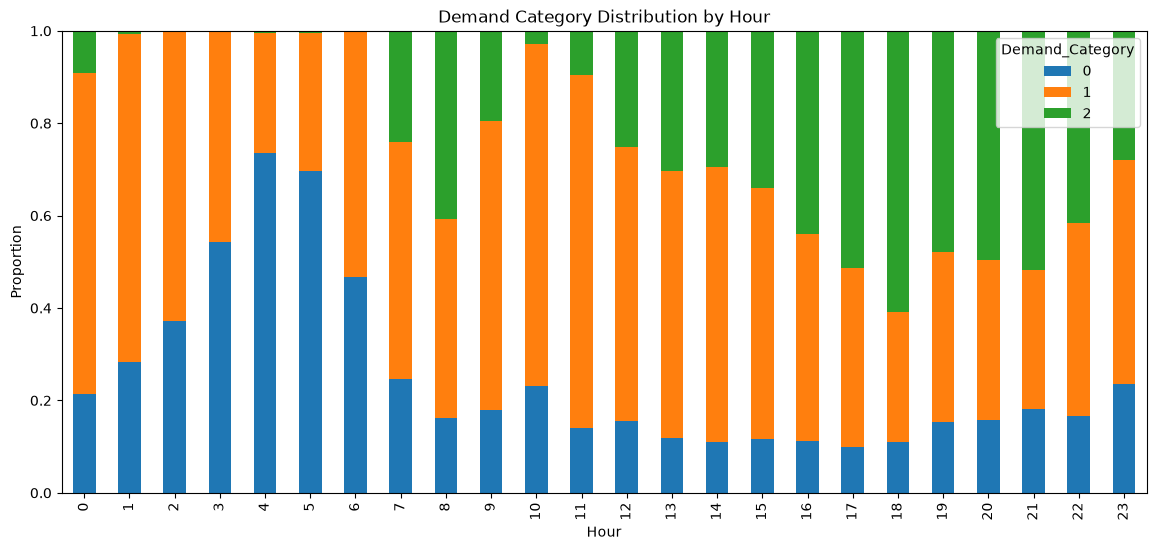

In [25]:
hour_class_distribution.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6)
)

plt.title("Demand Category Distribution by Hour")
plt.xlabel("Hour")
plt.ylabel("Proportion")
plt.legend(title="Demand_Category")
plt.show()

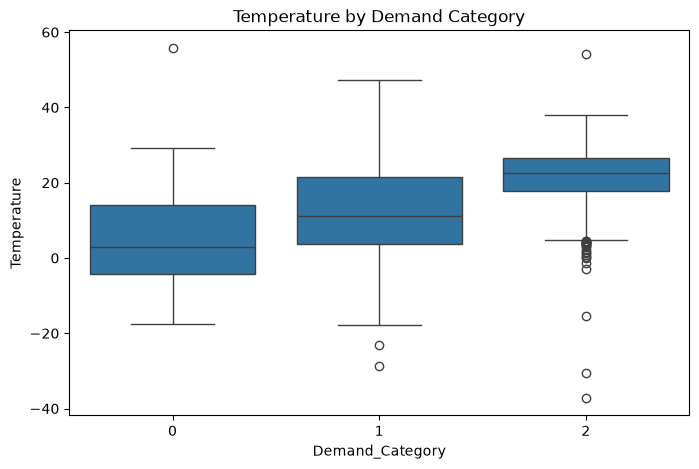

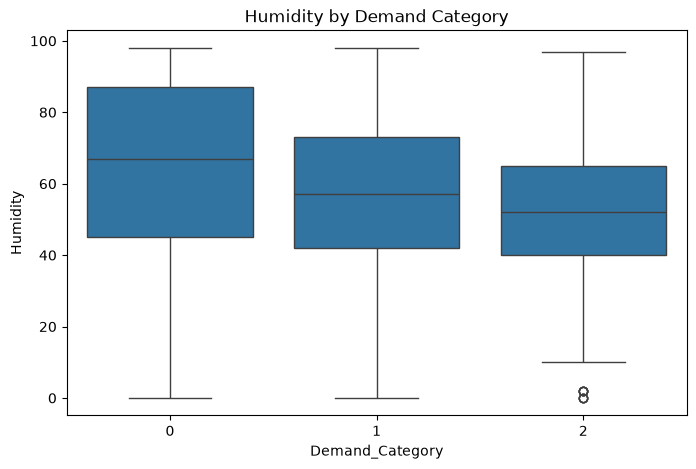

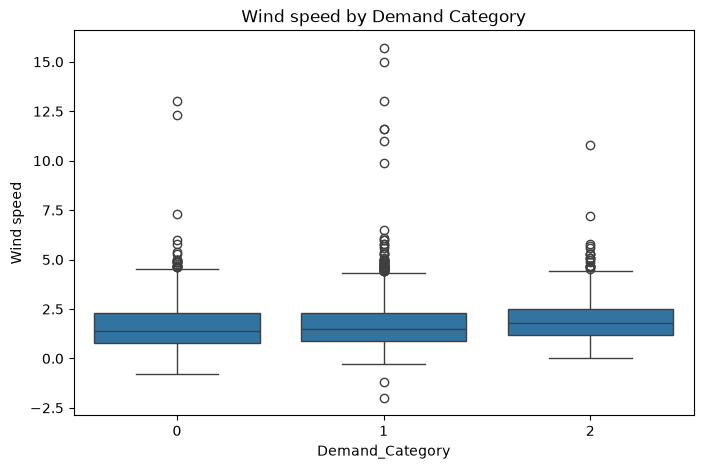

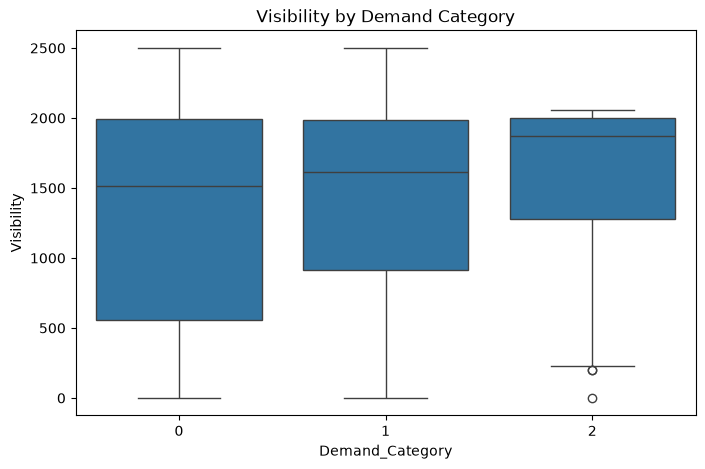

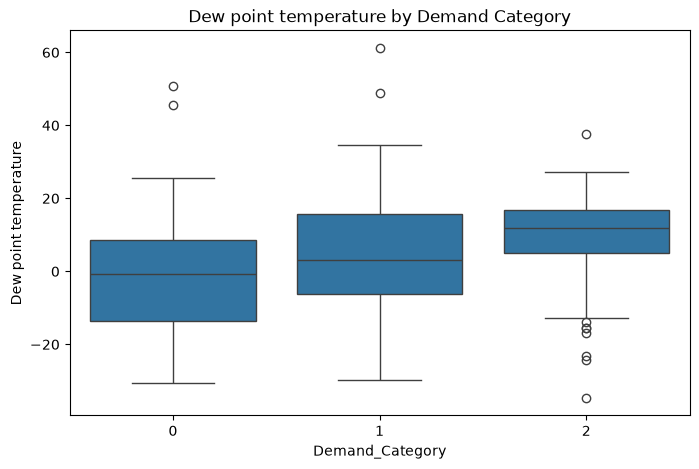

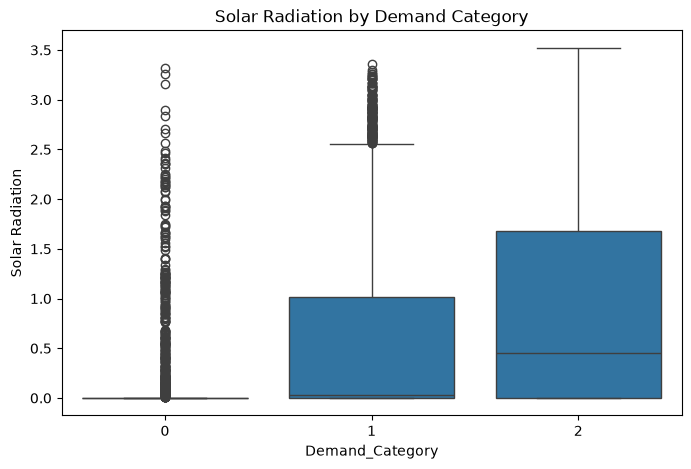

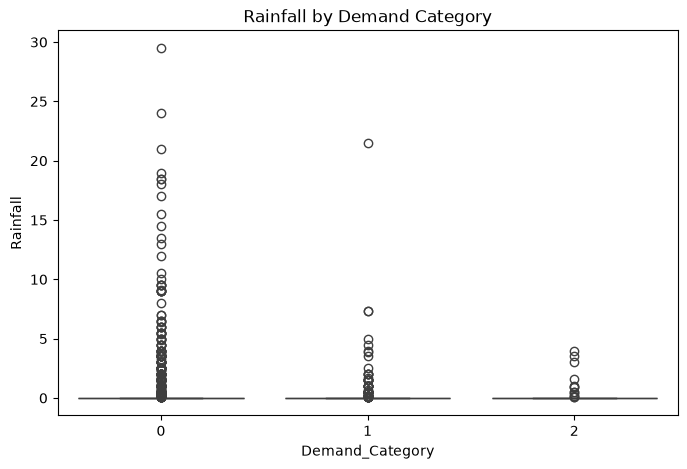

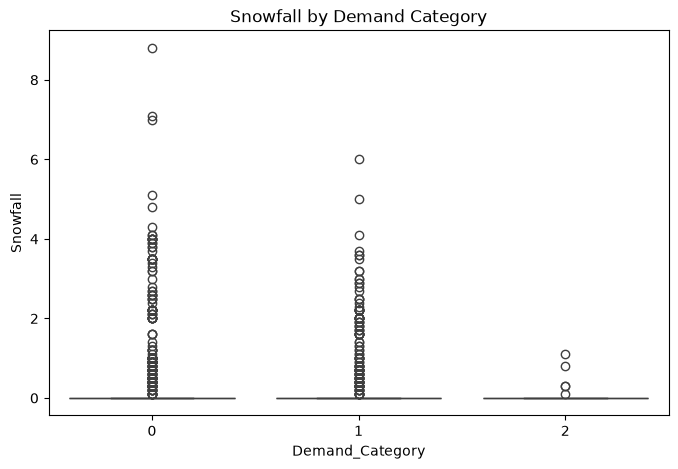

In [26]:
numeric_features = [
    "Temperature",
    "Humidity",
    "Wind speed",
    "Visibility",
    "Dew point temperature",
    "Solar Radiation",
    "Rainfall",
    "Snowfall"
]

for col in numeric_features:
    plt.figure(figsize=(8, 5))
    
    sns.boxplot(
        data=df_train,
        x="Demand_Category",
        y=col
    )
    
    plt.title(f"{col} by Demand Category")
    plt.show()

In [27]:
for col in X.columns:
    if df_train[col].isna().any():
        print(f"\n{col}")
        print(
            df_train
            .groupby("Demand_Category")[col]
            .apply(lambda s: s.isna().mean())
        )


Temperature
Demand_Category
0    0.024299
1    0.027035
2    0.030025
Name: Temperature, dtype: float64

Wind speed
Demand_Category
0    0.044860
1    0.042262
2    0.045343
Name: Wind speed, dtype: float64

Solar Radiation
Demand_Category
0    0.089720
1    0.091050
2    0.094975
Name: Solar Radiation, dtype: float64

Rainfall
Demand_Category
0    0.068536
1    0.072094
2    0.066789
Name: Rainfall, dtype: float64


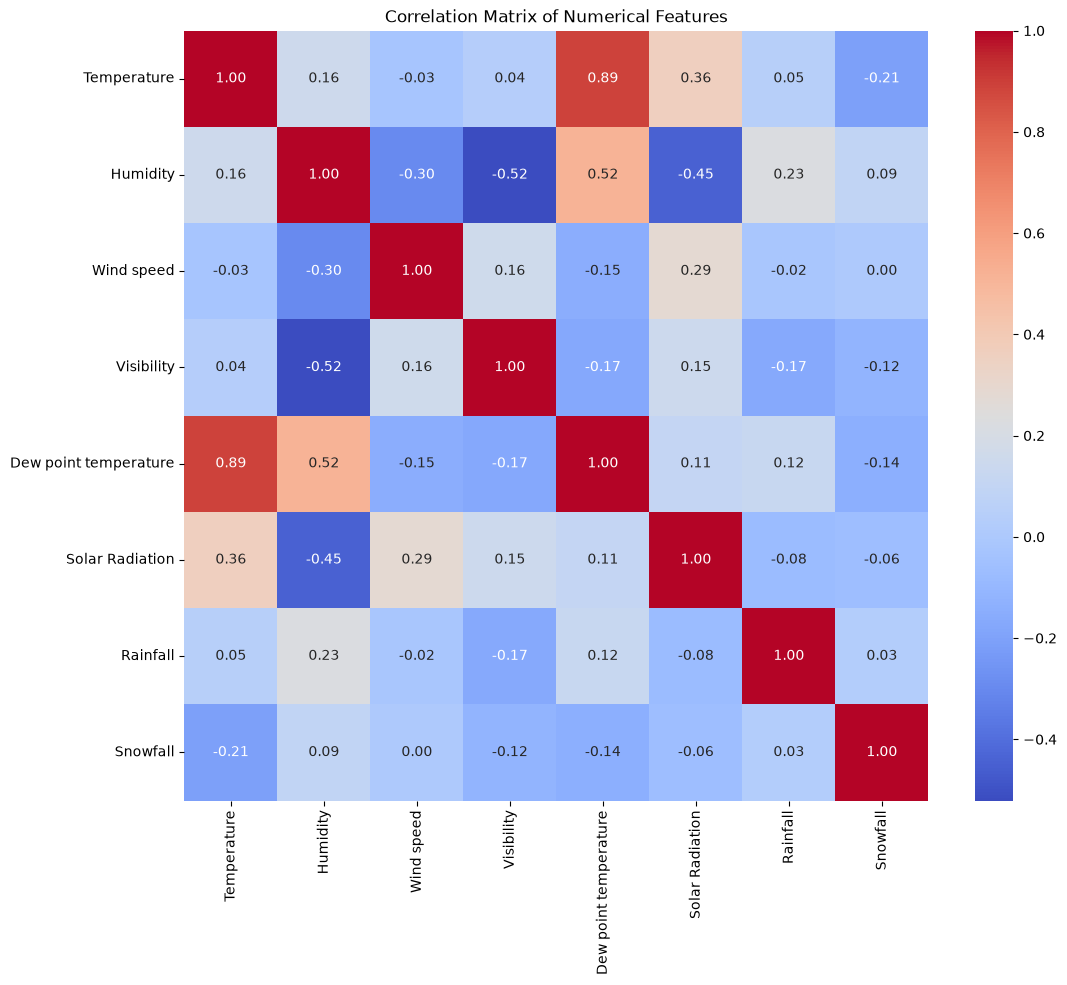

In [28]:
plt.figure(figsize=(12, 10))

corr = df_train[numeric_features].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

### Further domain-validity checks

The remaining numeric columns are checked against their physically valid ranges: `Hour` against [0, 23], `Humidity` against [0, 100]%, `Wind speed` and `Rainfall` against being non-negative, and `Dew point temperature` against never exceeding the actual `Temperature` (dew point is bounded above by air temperature by definition). Note that the `Hour` range check below runs after the `Hour < 0` rows were already dropped in the previous cell, so it only confirms a clean [0, 23] range post hoc rather than being the step that originally caught the problem. The `Humidity` and `Rainfall` checks find no out-of-range rows, but 6 rows have negative `Wind speed` and 11 rows have a `Dew point temperature` exceeding `Temperature` — both physically impossible and indicative of faulty readings that motivate the anomaly filters applied next.

In [29]:
print(df_train["Hour"].min())
print(df_train["Hour"].max())

display(
    df_train[
        (df_train["Hour"] < 0) |
        (df_train["Hour"] > 23)
    ]
)

0
23


,Kaggle_ID,Date,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day,Record_id,Demand_Category,Month


In [30]:
display(
    df_train[
        (df_train["Humidity"] < 0) |
        (df_train["Humidity"] > 100)
    ]
)

,Kaggle_ID,Date,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day,Record_id,Demand_Category,Month


In [31]:
display(
    df_train[
        df_train["Wind speed"] < 0
    ]
)

,Kaggle_ID,Date,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day,Record_id,Demand_Category,Month
96,96,4/3/2018,8,-9.7,0,-0.8,309,-22.8,1.07,0.0,0.0,Spring,No Holiday,No,905594,0,3
2796,2796,19/01/2018,9,8.3,1,-1.2,925,-29.9,2.22,0.7,1.4,Winter,Holiday,Yes,3436601,1,1
4844,4844,6/3/2018,20,8.6,2,-2.0,0,32.7,0.56,1.7,0.7,Spring,No Holiday,Yes,5553996,1,3
4957,4957,3/4/2018,0,47.3,0,-0.3,2,10.5,NaN,0.0,0.3,Spring,No Holiday,No,4082723,1,4
5745,5745,4/3/2018,8,-9.7,0,-0.8,309,-22.8,1.07,0.0,0.0,Spring,No Holiday,No,905594,0,3
6195,6195,3/4/2018,0,47.3,0,-0.3,2,10.5,NaN,0.0,0.3,Spring,No Holiday,No,4082723,1,4


In [32]:
display(
    df_train[
        df_train["Rainfall"] < 0
    ]
)

,Kaggle_ID,Date,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day,Record_id,Demand_Category,Month


In [33]:
display(
    df_train[
        df_train["Snowfall"] < 0
    ]
)

,Kaggle_ID,Date,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day,Record_id,Demand_Category,Month


In [34]:
display(
    df_train[
        df_train["Dew point temperature"] >
        df_train["Temperature"]
    ]
)

,Kaggle_ID,Date,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day,Record_id,Demand_Category,Month
1,1,7/9/2018,23,12.9,0,2.4,1688,50.9,0.00,2.4,1.4,Autumn,No Holiday,No,1465289,0,9
1619,1619,4/11/2018,0,-23.1,0,0.6,686,61.2,0.00,1.5,1.2,Autumn,No Holiday,No,5574271,1,11
2140,2140,25/03/2018,23,-15.4,0,2.1,1241,37.6,NaN,0.0,0.0,Spring,No Holiday,Yes,8476811,2,3
2731,2731,24/11/2018,23,-11.0,1,0.4,1799,2.1,0.25,0.0,0.5,Autumn,No Holiday,No,1449653,1,11
3293,3293,17/01/2018,23,-28.6,1,3.1,2167,24.4,0.34,0.0,0.0,Winter,Holiday,Yes,5730744,1,1
4024,4024,4/10/2018,20,-10.6,1,3.0,0,25.6,NaN,1.5,0.1,Autumn,No Holiday,Yes,649071,0,10
4720,4720,21/11/2018,0,-37.2,0,4.7,1894,-16.8,1.93,3.0,0.0,Autumn,Holiday,Yes,6449605,2,11
4844,4844,6/3/2018,20,8.6,2,-2.0,0,32.7,0.56,1.7,0.7,Spring,No Holiday,Yes,5553996,1,3
4989,4989,17/09/2018,20,-5.7,2,5.7,463,34.7,0.59,0.0,0.0,Autumn,No Holiday,No,3718446,1,9
5065,5065,17/01/2018,23,-4.3,2,2.1,1724,45.7,1.41,3.7,0.9,Winter,No Holiday,No,1006766,0,1


## 4. Anomaly Masks and Parallel Dataset Variants

Beyond the checks above, five physically-invalid-value conditions are defined and applied across the (now 6,455-row) dataset:

- **Humidity**: values below 7% are treated as implausibly low for the region and flagged.
- **Wind speed**: negative values, or values above 64 (an extreme, implausible upper bound for surface wind speed), are flagged.
- **Solar Radiation**: nonzero readings recorded at night (Hour ≥ 20 or Hour < 5, when there is no sunlight to measure) are flagged, as are readings above a plausible ceiling of 4.0.
- **Rainfall**: negative values, or values above 146.0 (beyond the highest plausible hourly rainfall for the region), are flagged.
- **Temperature**: flagged when it falls outside a season-specific plausible range — Spring [-3, 32], Summer [16, 39.6], Autumn [0, 30], Winter [-17, 11] — since a temperature can be within the dataset's overall range while still being impossible for the season it is dated in.

Combined, these conditions flag 144 rows (6,455 rows before filtering vs. 6,311 rows remaining once anomalous rows are dropped for the dense variants below).

### Why five dataset variants instead of one

There are two independent design decisions in cleaning this data, and neither has an obviously correct answer in isolation: whether rows with a physically invalid value should be **dropped** or have just that value **nulled and preserved**, and whether missing values (original or newly-nulled) should be **dropped** or **imputed**. Rather than picking one combination, all relevant combinations are materialized as separate CSV files, so that later modeling can treat the cleaning strategy itself as a hyperparameter and compare macro-F1 across variants empirically:

- `train_clean_nan`: anomalous rows dropped; original missing values (Temperature, Wind speed, Solar Radiation, Rainfall) left as NaN.
- `train_clean`: anomalous rows dropped, then any row still containing a NaN is also dropped — fully dense, at the cost of more rows lost.
- `train_clean_imputed`: same anomalous-row-dropped base as `train_clean_nan`, but remaining NaNs are filled (`IterativeImputer` for numeric columns, most-frequent `SimpleImputer` for categorical columns) instead of dropped — dense, without discarding rows.
- `train_preserved_nan`: no rows dropped for anomalies; anomalous values are nulled in place, so every row is kept but with additional missingness on top of the original.
- `train_preserved_imputed`: the preserved variant with all missing values (original and anomaly-induced) imputed — dense, and keeps every original row.

In [35]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer

# --- 1. Define Features for Imputation ---
numerical_features = [
    'Hour', 'Temperature', 'Humidity', 'Wind speed', 'Visibility', 
    'Dew point temperature', 'Solar Radiation', 'Rainfall', 'Snowfall'
]
categorical_features = ['Seasons', 'Holiday', 'Functioning Day'] 

# --- 2. Reusable Imputation Function ---
def impute_dataset(df, numeric_cols, categorical_cols):
    print("Starting imputation...")
    df_imputed = df.copy()
    
    if categorical_cols:
        cat_imputer = SimpleImputer(strategy='most_frequent')
        df_imputed[categorical_cols] = cat_imputer.fit_transform(df_imputed[categorical_cols])
        
    if numeric_cols:
        num_imputer = IterativeImputer(max_iter=10, random_state=42)
        df_imputed[numeric_cols] = num_imputer.fit_transform(df_imputed[numeric_cols])
        if 'Hour' in numeric_cols:
            df_imputed['Hour'] = df_imputed['Hour'].round().astype(int)
            
    return df_imputed

print(f"Number of rows before anomaly removal: {df_train.shape[0]}")

# --- 3. Generate Anomaly Masks ---
invalid_humidity = df_train['Humidity'] < 7
invalid_wind = (df_train['Wind speed'] < 0) | (df_train['Wind speed'] > 64)
invalid_solar_night = ((df_train['Hour'] >= 20) | (df_train['Hour'] < 5)) & (df_train['Solar Radiation'] > 0)
invalid_solar_max = df_train['Solar Radiation'] > 4.0
invalid_rain = (df_train['Rainfall'] < 0) | (df_train['Rainfall'] > 146.0)

spring_invalid = (df_train['Seasons'] == 'Spring') & ((df_train['Temperature'] < -3.0) | (df_train['Temperature'] > 32.0))
summer_invalid = (df_train['Seasons'] == 'Summer') & ((df_train['Temperature'] < 16.0) | (df_train['Temperature'] > 39.6))
autumn_invalid = (df_train['Seasons'] == 'Autumn') & ((df_train['Temperature'] < 0.0) | (df_train['Temperature'] > 30.0))
winter_invalid = (df_train['Seasons'] == 'Winter') & ((df_train['Temperature'] < -17.0) | (df_train['Temperature'] > 11.0))
invalid_temp = spring_invalid | summer_invalid | autumn_invalid | winter_invalid

# Combined mask for dropping entire rows (filled with False to prevent dropping existing NaNs)
all_anomalies = (invalid_humidity | invalid_wind | invalid_solar_night | invalid_solar_max | invalid_rain | invalid_temp).fillna(False)


# ==========================================
# DATASET GENERATION & SAVING
# ==========================================

# --- Dataset 2: Cleaned with NaN ---
# (Rows with anomalies are dropped, initial NaNs are kept)
train_clean_nan = df_train[~all_anomalies].copy()
train_clean_nan.to_csv('train_clean_nan.csv', index=False)
print(f"Saved Dataset 2 (Cleaned with NaN). Rows: {train_clean_nan.shape[0]}")

# --- Dataset 1: Fully cleaned with removed NaNs ---
# (Rows with anomalies are dropped, AND rows with NaNs are dropped)
train_clean = train_clean_nan.dropna().copy()
train_clean.to_csv('train_clean.csv', index=False)
print(f"Saved Dataset 1 (Fully cleaned, no NaNs). Rows: {train_clean.shape[0]}")

# --- Dataset 3: Cleaned with imputed initial NaNs ---
# (Rows with anomalies are dropped, initial NaNs are imputed)
train_clean_imputed = impute_dataset(train_clean_nan, numerical_features, categorical_features)
train_clean_imputed.to_csv('train_clean_imputed.csv', index=False)
print(f"Saved Dataset 3 (Cleaned and Imputed). Rows: {train_clean_imputed.shape[0]}")

# --- Dataset 4: Anomaly values converted to NaNs ---
# (No rows dropped. Only the specific anomalous cells are replaced with NaN)
train_preserved_nan = df_train.copy()
train_preserved_nan.loc[invalid_humidity.fillna(False), 'Humidity'] = np.nan
train_preserved_nan.loc[invalid_wind.fillna(False), 'Wind speed'] = np.nan
train_preserved_nan.loc[(invalid_solar_night | invalid_solar_max).fillna(False), 'Solar Radiation'] = np.nan
train_preserved_nan.loc[invalid_rain.fillna(False), 'Rainfall'] = np.nan
train_preserved_nan.loc[invalid_temp.fillna(False), 'Temperature'] = np.nan

train_preserved_nan.to_csv('train_preserved_nan.csv', index=False)
print(f"Saved Dataset 4 (Anomalies converted to NaNs). Rows: {train_preserved_nan.shape[0]}")

# --- Dataset 5: Anomaly values converted and all NaNs imputed ---
# (Takes Dataset 4 and runs it through the imputer)
train_preserved_imputed = impute_dataset(train_preserved_nan, numerical_features, categorical_features)
train_preserved_imputed.to_csv('train_preserved_imputed.csv', index=False)
print(f"Saved Dataset 5 (Preserved and Fully Imputed). Rows: {train_preserved_imputed.shape[0]}")

Number of rows before anomaly removal: 6455
Saved Dataset 2 (Cleaned with NaN). Rows: 6311
Saved Dataset 1 (Fully cleaned, no NaNs). Rows: 4949
Starting imputation...
Saved Dataset 3 (Cleaned and Imputed). Rows: 6311
Saved Dataset 4 (Anomalies converted to NaNs). Rows: 6455
Starting imputation...
Saved Dataset 5 (Preserved and Fully Imputed). Rows: 6455


c:\Users\VivoBook Pro 16x\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


## 5. Output Summary

Five cleaned training-set variants are written to disk, reflecting the anomaly-handling × missing-value-handling combinations above:

| File | Anomalies | Missing values | Rows |
|---|---|---|---|
| `train_clean_nan.csv` | dropped | left as NaN | 6,311 |
| `train_clean.csv` | dropped | dropped | 4,949 |
| `train_clean_imputed.csv` | dropped | imputed | 6,311 |
| `train_preserved_nan.csv` | nulled in place | left as NaN | 6,455 |
| `train_preserved_imputed.csv` | nulled in place | imputed | 6,455 |

All five variants trace back to the same 6,455-row post-`Hour`-filter dataset; they differ only in how the physically invalid values and the missing values are treated, leaving the choice between them to be resolved empirically by comparing downstream macro-F1 rather than fixed here.